# 05. Advanced Models (Gradient Boosting)

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb, including the Week 6 engineered features `BedBathRatio` / `PropertyAge` / `SchoolDistrictGIS`, with `Latitude`/`Longitude` excluded).

Here we try two gradient boosting implementations, **XGBoost** and **LightGBM**, doing a light hyperparameter search over `max_depth` / `learning_rate` / `n_estimators` (plus `num_leaves` for LightGBM specifically - see section 4) for each, and report test-set metrics, including a like-for-like comparison against Linear Regression and Random Forest retrained on this exact same data

**Note on tuning methodology**: earlier notebooks (e.g. the train-window search in 02_preprocessing.ipynb) picked their setting by checking directly against the test month. Here a proper validation split carved out of the training window is used for hyperparameter tuning instead, so the true test month stays untouched until the very last step (section 6).


In [107]:
import re
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs xgboost. Install with: pip install xgboost"
    ) from e

try:
    from lightgbm import LGBMRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs lightgbm. Install with: pip install lightgbm"
    ) from e

RANDOM_STATE = 42


## 1. Load cleaned dataset


In [108]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
print(cleaned_df.shape)
cleaned_df["split"].value_counts()


(138859, 120)


split
train    126835
test      12024
Name: count, dtype: int64

In [109]:
cleaned_df[cleaned_df["ClosePrice"] <= 0]

,num__LivingArea,num__DaysOnMarket,num__ParkingTotal,num__LotSizeAcres,num__YearBuilt,num__BathroomsTotalInteger,num__BedroomsTotal,num__Stories,num__LotSizeArea,num__MainLevelBedrooms,...,cat__missingindicator_Levels_False,cat__missingindicator_Levels_True,cat__missingindicator_NewConstructionYN_False,cat__missingindicator_NewConstructionYN_True,cat__missingindicator_SchoolDistrictGIS_False,cat__missingindicator_SchoolDistrictGIS_True,ClosePrice,year_month,date,split


## 2. Separate features / target using the `split` column

Same pattern as 03_baseline_model.ipynb / 04_model_comparison.ipynb: `split == "train"` for training, `split == "test"` for the held-out final evaluation (the most recent month, never touched until section 6).

Feature column names are sanitized before use: several are one-hot columns from the multi-label `Flooring` encoding (02_preprocessing.ipynb section 5), e.g. `cat__Flooring_Bamboo,Carpet,Laminate`, and LightGBM's parser rejects feature names containing certain JSON special characters (`, : [ ] { } "`) - XGBoost happens to tolerate them, but they're replaced with `_` for both models here so the two stay on identical column names.


In [110]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

def sanitize_feature_name(name):
    # LightGBM rejects these JSON special characters in feature names; XGBoost tolerates them,
    # but both models are kept on identical (sanitized) column names to avoid any mismatch.
    return re.sub(r'[",:\[\]{}]', "_", name)

raw_feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]
sanitized_names = [sanitize_feature_name(c) for c in raw_feature_cols]

if len(set(sanitized_names)) != len(sanitized_names):
    # Extremely unlikely with this data, but guard against two different raw names colliding
    # onto the same sanitized name (e.g. "A,B" and "A:B" both becoming "A_B").
    seen = {}
    deduped = []
    for name in sanitized_names:
        seen[name] = seen.get(name, 0) + 1
        deduped.append(name if seen[name] == 1 else f"{name}_{seen[name]}")
    sanitized_names = deduped

cleaned_df = cleaned_df.rename(columns=dict(zip(raw_feature_cols, sanitized_names)))
feature_cols = sanitized_names

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# Log-transform the target. ClosePrice is strictly > 0 (filtered in 02_preprocessing),
# so log1p is safe; models are trained on this and predictions are back-transformed
# with expm1 before scoring, so all metrics stay in the original $ scale.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (126835, 116) | X_test: (12024, 116)


## 3. Validation split for tuning (single hold-out, not CV)

Rather than walk-forward CV folds, hyperparameter tuning here uses a single validation split: the last month inside the training window is held out as validation, and every month before it is used to fit each candidate model. This keeps the search simple and fast, and - just like a CV-based approach would - never touches the true test month (section 2) until the final evaluation in section 6.

In [111]:
months_in_train = sorted(train_df["year_month"].unique())
val_month = months_in_train[-1]

tune_train_df = train_df[train_df["year_month"] != val_month]
val_df = train_df[train_df["year_month"] == val_month]

X_tune_train = tune_train_df[feature_cols]
y_tune_train_log = np.log1p(tune_train_df[target])

X_val = val_df[feature_cols]
y_val = val_df[target]

print(f"Validation month: {val_month}")
print(f"X_tune_train: {X_tune_train.shape} | X_val: {X_val.shape}")

Validation month: 2026-04
X_tune_train: (115106, 116) | X_val: (11729, 116)


## 4. Hyperparameter grids

A light grid is used for each model: `max_depth` x `learning_rate` x `n_estimators` (12 combinations). LightGBM also varies `num_leaves`, since it grows trees leaf-wise rather than depth-wise, so `max_depth` alone doesn't control its complexity the way it does for XGBoost - candidates are kept at or below `2^max_depth` for each depth so the comparison stays fair.

In [112]:
xgb_param_grid = list(itertools.product(
    [3, 5, 7],      # max_depth
    [0.05, 0.1],    # learning_rate
    [100, 300],     # n_estimators
))

def num_leaves_candidates(max_depth):
    # kept at/below 2**max_depth (capped at 63) so num_leaves never lets a shallow
    # tree grow more complex than max_depth would otherwise allow
    return sorted(set(min(2 ** d, 63) for d in (max_depth - 1, max_depth)))

lgbm_param_grid = [
    (max_depth, learning_rate, n_estimators, num_leaves)
    for max_depth, learning_rate, n_estimators in xgb_param_grid
    for num_leaves in num_leaves_candidates(max_depth)
]

print(f"XGBoost grid: {len(xgb_param_grid)} combinations")
print(f"LightGBM grid: {len(lgbm_param_grid)} combinations")

XGBoost grid: 12 combinations
LightGBM grid: 20 combinations


## 5. Run the grid search (score on the validation split)

Each candidate is fit on `X_tune_train` (log-target) and scored against `X_val` using R^2, MAE, and RMSE (predictions are back-transformed to the original $ scale before scoring). Results for both models are collected into one table, tagged by the `gbm` column, and saved to `advanced_model_tuning_results.csv`.

In [113]:
def evaluate(model, X, y):
    # model was trained on log1p(target); expm1 converts predictions back to the
    # original $ scale before scoring against y (which is always the raw $ scale)
    pred = np.expm1(model.predict(X))
    return {
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
    }

tuning_rows = []

for max_depth, learning_rate, n_estimators in xgb_param_grid:
    model = XGBRegressor(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tune_train, y_tune_train_log)
    metrics = evaluate(model, X_val, y_val)
    tuning_rows.append({
        "gbm": "XGBoost",
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "num_leaves": np.nan,
        **metrics,
    })

for max_depth, learning_rate, n_estimators, num_leaves in lgbm_param_grid:
    model = LGBMRegressor(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        num_leaves=num_leaves,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(X_tune_train, y_tune_train_log)
    metrics = evaluate(model, X_val, y_val)
    tuning_rows.append({
        "gbm": "LightGBM",
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "num_leaves": num_leaves,
        **metrics,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("R2", ascending=False).reset_index(drop=True)
tuning_results.to_csv("advanced_model_tuning_results.csv", index=False)
print("Saved advanced_model_tuning_results.csv")
tuning_results.head(10)

Saved advanced_model_tuning_results.csv


,gbm,max_depth,learning_rate,n_estimators,num_leaves,R2,MAE,RMSE
0,XGBoost,7,0.10,300,NaN,0.885965,157188.498974,269904.586752
1,LightGBM,7,0.10,300,63.0,0.884407,157603.019364,271742.204672
2,XGBoost,7,0.05,300,NaN,0.881493,159827.626691,275146.107950
3,LightGBM,7,0.05,300,63.0,0.881202,160700.165639,275483.999816
4,LightGBM,5,0.10,300,32.0,0.880247,161274.740964,276588.773904
5,XGBoost,5,0.10,300,NaN,0.879964,161841.504127,276915.274899
6,XGBoost,7,0.10,100,NaN,0.879126,162350.079047,277880.252518
7,LightGBM,5,0.10,300,16.0,0.877493,163365.047787,279751.316510
8,LightGBM,7,0.10,100,63.0,0.877330,163451.688202,279937.057391
9,XGBoost,5,0.05,300,NaN,0.875848,165169.576919,281622.959697


## 6. Refit the best configuration on the full training window, evaluate once on the test month

For each model, the configuration with the highest validation R^2 (section 5) is selected, refit on the full `X_train` (all months, not just the tuning subset), and evaluated a single time on the true test month held out since section 2.

In [114]:
gbm_best_params = {}

best_xgb_row = (
    tuning_results[tuning_results["gbm"] == "XGBoost"]
    .sort_values("R2", ascending=False)
    .iloc[0]
)
xgb_best_config = {
    "max_depth": int(best_xgb_row["max_depth"]),
    "learning_rate": float(best_xgb_row["learning_rate"]),
    "n_estimators": int(best_xgb_row["n_estimators"]),
}
gbm_best_params["XGBoost"] = xgb_best_config

xgb_model = XGBRegressor(**xgb_best_config, random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train, y_train_log)
xgb_test_metrics = evaluate(xgb_model, X_test, y_test)

best_lgbm_row = (
    tuning_results[tuning_results["gbm"] == "LightGBM"]
    .sort_values("R2", ascending=False)
    .iloc[0]
)
lgbm_best_config = {
    "max_depth": int(best_lgbm_row["max_depth"]),
    "learning_rate": float(best_lgbm_row["learning_rate"]),
    "n_estimators": int(best_lgbm_row["n_estimators"]),
    "num_leaves": int(best_lgbm_row["num_leaves"]),
}
gbm_best_params["LightGBM"] = lgbm_best_config

lgbm_model = LGBMRegressor(**lgbm_best_config, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train_log)
lgbm_test_metrics = evaluate(lgbm_model, X_test, y_test)

print(f"XGBoost best params: {xgb_best_config}")
print(f"XGBoost test metrics: {xgb_test_metrics}")
print(f"LightGBM best params: {lgbm_best_config}")
print(f"LightGBM test metrics: {lgbm_test_metrics}")

XGBoost best params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 300}
XGBoost test metrics: {'R2': 0.39916122694513967, 'MAE': 240143.4635884481, 'RMSE': np.float64(1300728.0138277416)}
LightGBM best params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 300, 'num_leaves': 63}
LightGBM test metrics: {'R2': 0.4038999270847562, 'MAE': 239695.559345757, 'RMSE': np.float64(1295588.5641467064)}


## 7. Feature importance

XGBoost and LightGBM don't necessarily agree on which features matter most, even when both are gradient-boosted trees on the same data - comparing the two side by side shows how much (or little) that differs.


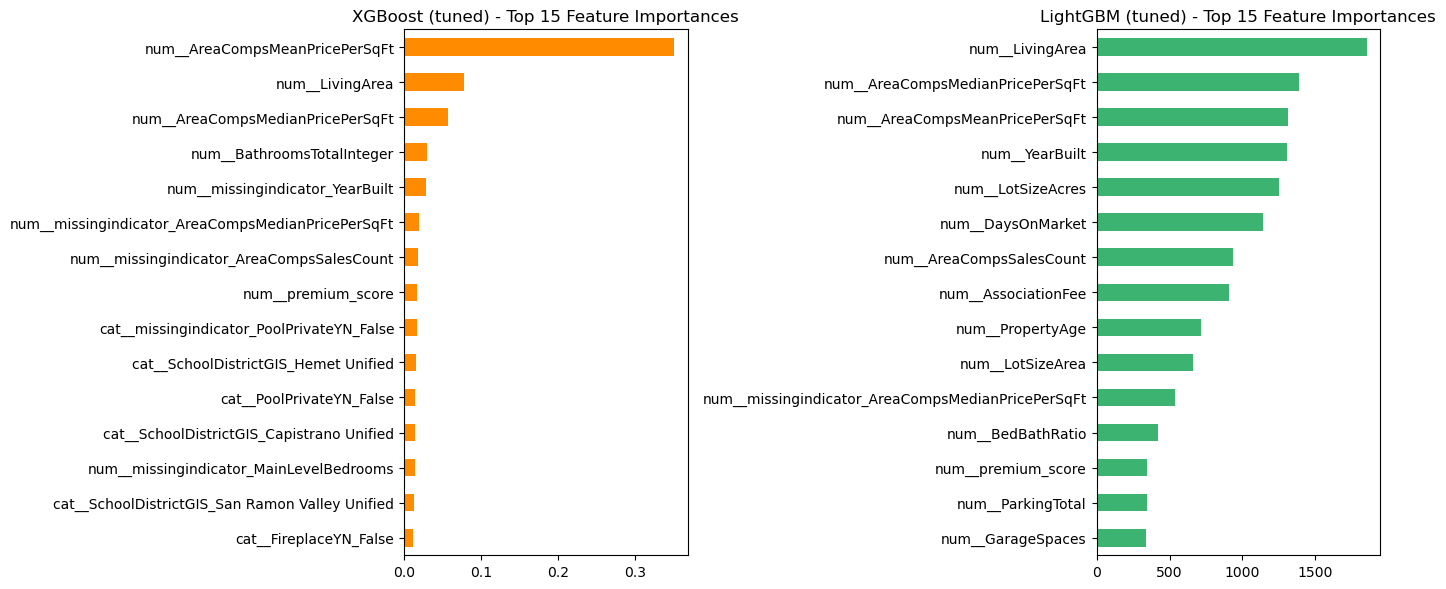

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importances.head(15).sort_values().plot(kind="barh", ax=axes[0], color="darkorange")
axes[0].set_title("XGBoost (tuned) - Top 15 Feature Importances")

lgbm_importances = pd.Series(lgbm_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
lgbm_importances.head(15).sort_values().plot(kind="barh", ax=axes[1], color="mediumseagreen")
axes[1].set_title("LightGBM (tuned) - Top 15 Feature Importances")

plt.tight_layout()
plt.show()


## 8. Compare against Linear Regression and Random Forest & record results

`LinearRegression` and `RandomForestRegressor (max_depth=5)` (the most stable Random Forest setting found in 04_model_comparison.ipynb) are retrained here on the exact same `X_train`/`X_test` used for the gradient boosting models above, rather than reusing `baseline_model_results.csv` / `model_comparison_results.csv` - those were generated before the Week 6 feature set existed, so pulling numbers from them here could compare the new models against ones trained on a different set of columns.


In [125]:
model_results = pd.read_csv("model_comparison_results.csv")

In [124]:
advanced_model_results = pd.DataFrame([
    {"model": f"XGBoost",
     "max_depth": f"{gbm_best_params['XGBoost']['max_depth']}",
     "learning_rate":f"{gbm_best_params['XGBoost']['learning_rate']}",
     "n_estimators":f"{gbm_best_params['XGBoost']['n_estimators']}",
      **xgb_test_metrics},
    {"model": f"LightGBM",
    "max_depth": f"{gbm_best_params['LightGBM']['max_depth']}",
     "learning_rate":f"{gbm_best_params['LightGBM']['learning_rate']}",
     "n_estimators":f"{gbm_best_params['LightGBM']['n_estimators']}",
      **lgbm_test_metrics},
])
advanced_model_results["n_train_rows"] = len(X_train)
advanced_model_results["n_test_rows"] = len(X_test)
advanced_model_results


,model,max_depth,learning_rate,n_estimators,R2,MAE,RMSE,n_train_rows,n_test_rows
0,XGBoost,7,0.1,300,0.399161,240143.463588,1.300728e+06,126835,12024
1,LightGBM,7,0.1,300,0.403900,239695.559346,1.295589e+06,126835,12024


In [127]:
advanced_model_results = pd.concat([model_results, advanced_model_results])

In [129]:
advanced_model_results = advanced_model_results.sort_values("R2", ascending=False).reset_index(drop=True)


In [130]:

advanced_model_results.to_csv("advanced_model_results.csv", index=False)
print("Saved advanced_model_results.csv")
advanced_model_results

Saved advanced_model_results.csv


,model,max_depth,n_train_rows,n_test_rows,R2,MAE,RMSE,learning_rate,n_estimators
0,LightGBM,7,126835,12024,0.403900,239695.559346,1.295589e+06,0.1,300
1,XGBoost,7,126835,12024,0.399161,240143.463588,1.300728e+06,0.1,300
2,RandomForest,unconstrained,126835,12024,0.375516,251936.571886,1.326076e+06,NaN,NaN
3,RandomForest,NaN,126835,12024,0.375516,251936.571886,1.326076e+06,NaN,NaN
4,DecisionTree,10,126835,12024,0.368952,278907.868930,1.333027e+06,NaN,NaN
5,DecisionTree,unconstrained,126835,12024,0.351130,319818.023353,1.351718e+06,NaN,NaN
6,LinearRegression,NaN,126835,12024,0.315919,306216.459773,1.387910e+06,NaN,NaN


## Summary

- Models: `XGBRegressor` and `LGBMRegressor`, each tuned via its own light grid search scored on a validation month, not the true test month. XGBoost's grid is `max_depth` × `learning_rate` × `n_estimators` ; LightGBM's also includes `num_leaves` 
- Section 8 places both gradient boosting models side-by-side with `LinearRegression` and `RandomForest (max_depth=5)`, all four retrained on the identical Week-6 feature set / train-test split, so the comparison in `advanced_model_results.csv` is apples-to-apples and doesn't rely on potentially stale results from 03_baseline_model.ipynb / 04_model_comparison.ipynb
- Feature importance (section 7) compares which features XGBoost vs. LightGBM each rely on most, alongside the Random Forest importances from 04_model_comparison.ipynb / 02_preprocessing.ipynb
- Deliverables: `advanced_model_tuning_results.csv` (validation grid for both models), `advanced_model_results.csv` (final test metrics: Linear Regression, Random Forest, XGBoost, LightGBM), this notebook (`05_advanced_models.ipynb`)
